In [24]:
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy
import skimage

from lamina.loading.album import Album
from PIL import Image

In [25]:
album = Album(
    format=["png", "bmp", "tif"],
    image_store=r"/mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy"
)

In [26]:
album.make_album()

Could not open /mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy/Michael Popcorn AFM/20191012 1 2/Pop 3.bmp.


In [27]:
photos = album.photos

### Where the fun begins

In [141]:
random_image = random.choice(sum([list(photos[_].values()) for _ in photos.keys()], start=list([])))

In [142]:
random_image.filename

'/mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy/Unknown Sample/5-13-19/7,0 Picture.tif'

In [ ]:
'/mnt/myshare/Hubby/School/Grad/Research/Borys/Data/Optical_Microscopy/Unknown Sample/5-13-19/7,0 Picture.tif'

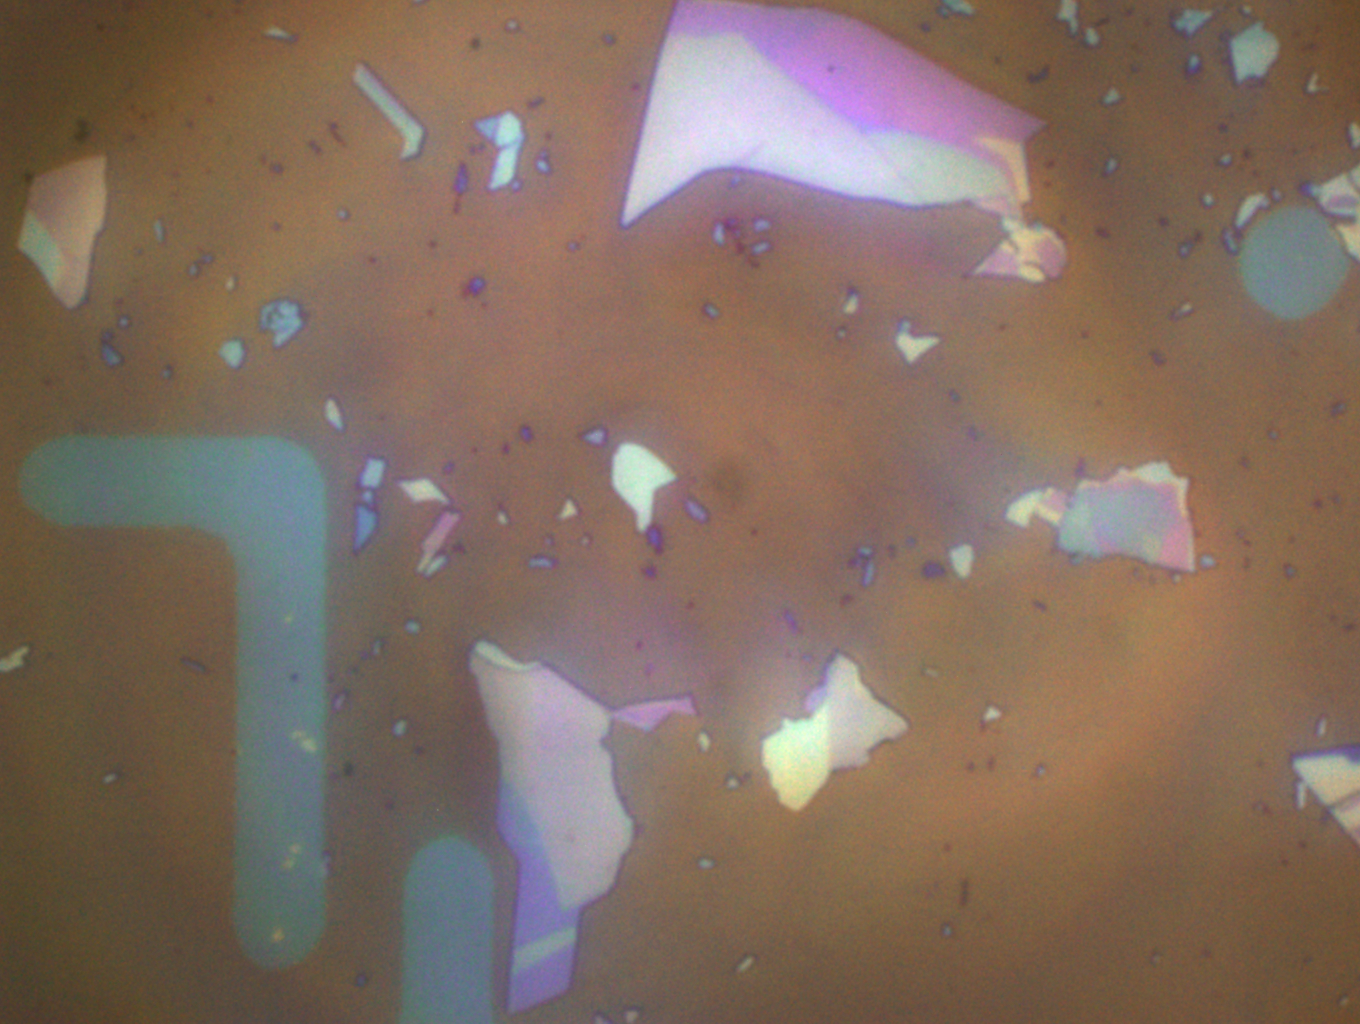

In [143]:
random_image

In [254]:
random_image_array = np.array(random_image)

### Masking all pixels that are in the labels and arrows

In [255]:
max_8_bit = 2 ** 8 - 1
min_8_bit = 0

black = [min_8_bit, min_8_bit, min_8_bit]
white = [max_8_bit, max_8_bit, max_8_bit]
red = [max_8_bit, min_8_bit, min_8_bit]
blue = [min_8_bit, min_8_bit, max_8_bit]

# Making the image mask.
mask_image = np.array(random_image)

# Checking for the colors we want to ignore in the original image.
black_mask = np.all(mask_image == black, axis=2)
white_mask = np.all(mask_image == white, axis=2)
red_mask = np.all(mask_image == red, axis=2)
blue_mask = np.all(mask_image == blue, axis=2)

label_mask = black_mask | white_mask | red_mask | blue_mask

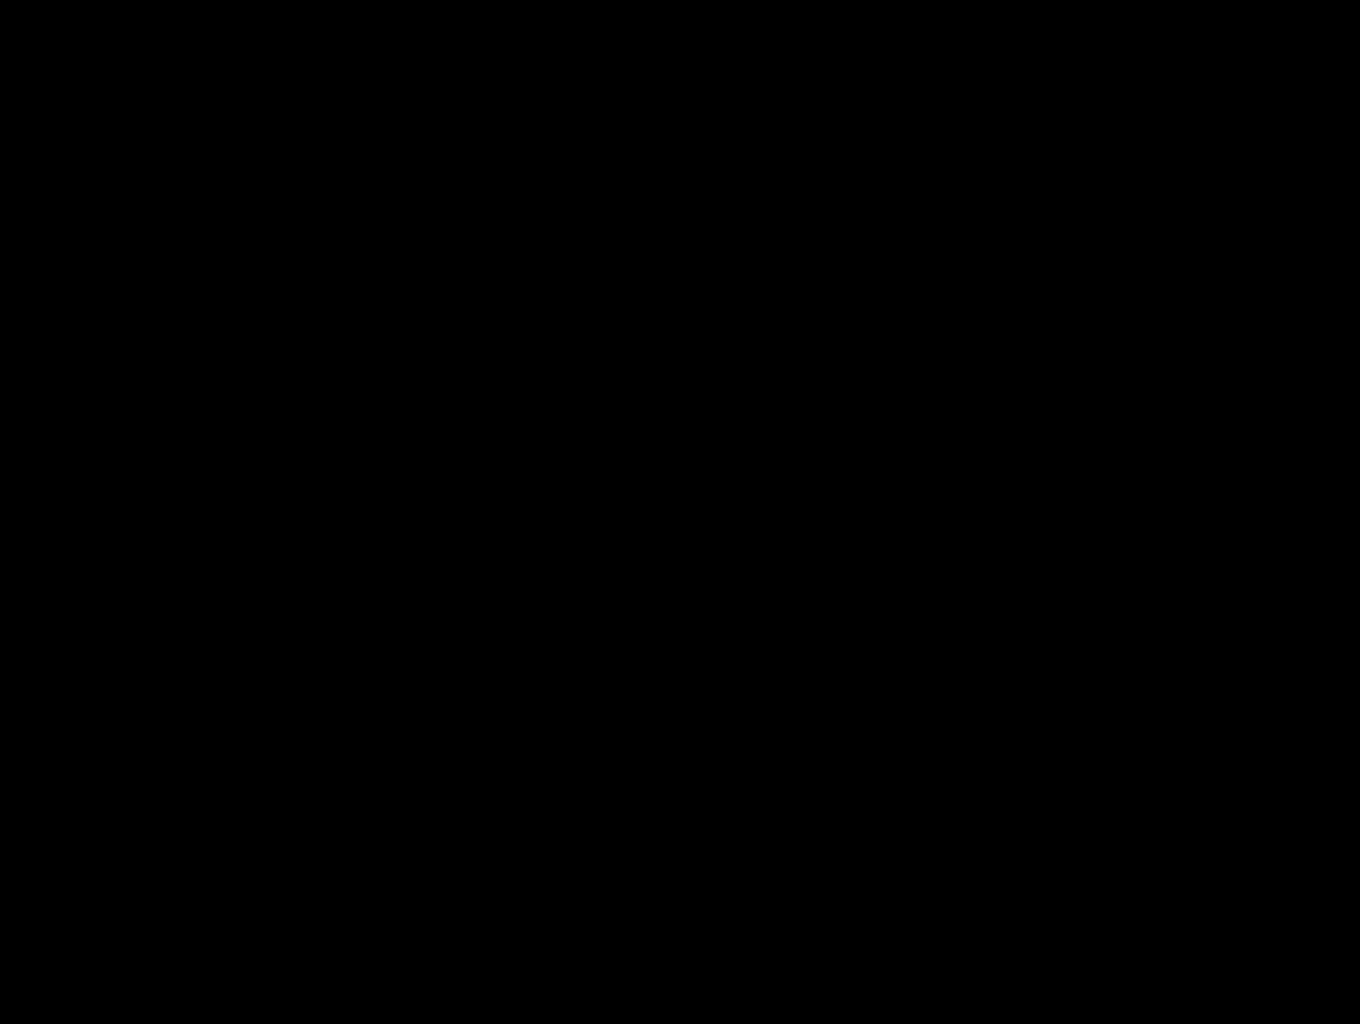

In [256]:
label_mask_image = Image.fromarray(label_mask)
label_mask_image

### Changing image to grayscale for easier thresholding

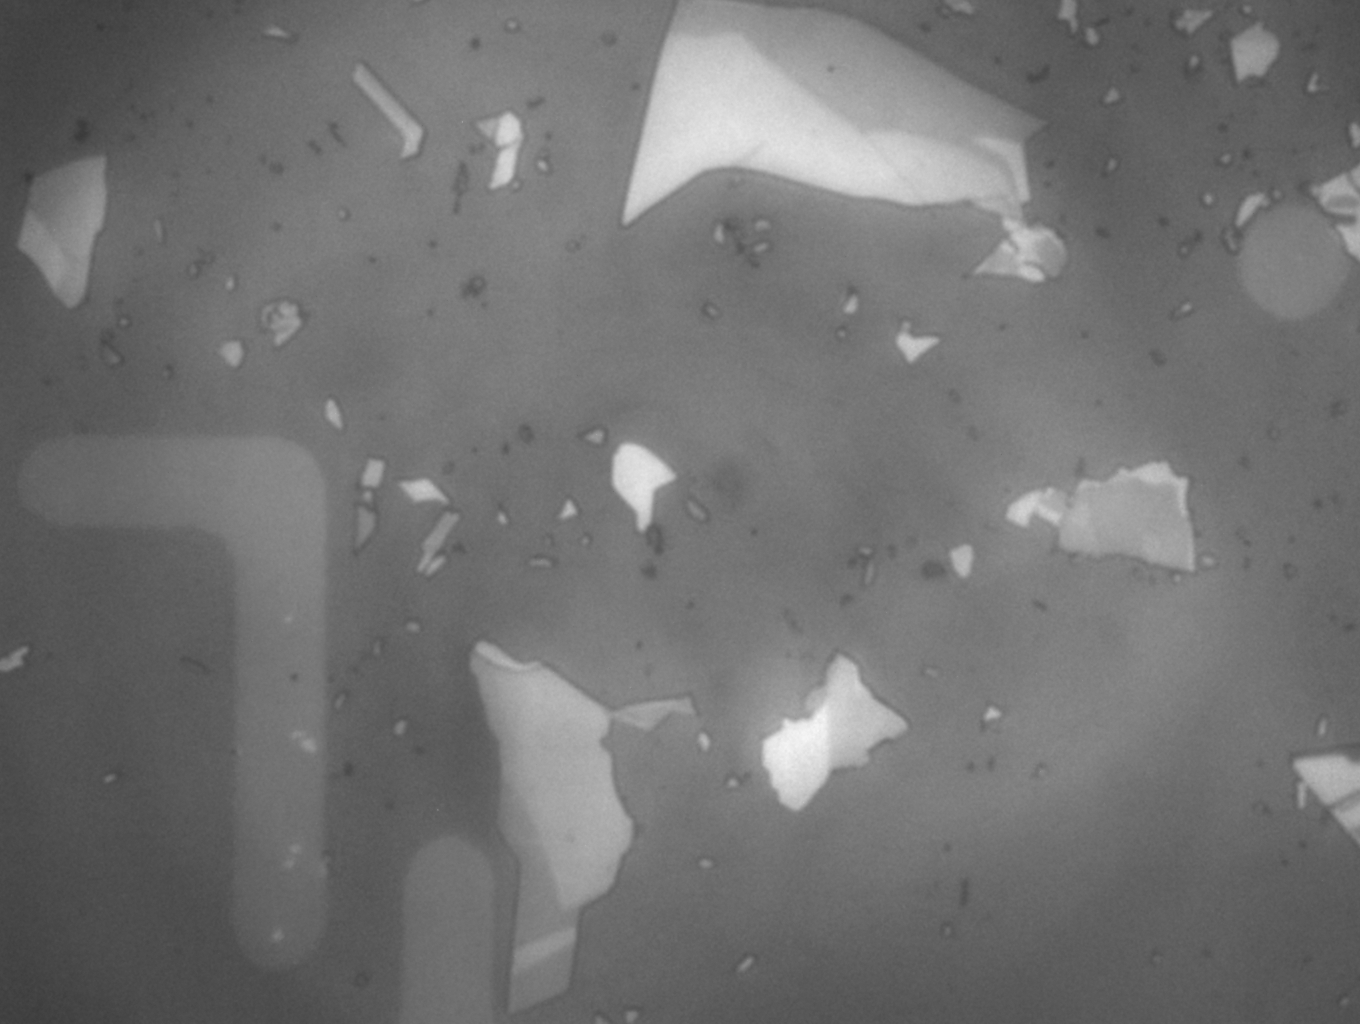

In [257]:
grayscale_image = random_image.convert("L")
grayscale_image

In [283]:
grayscale = np.array(grayscale_image)

In [ ]:
smoothed = np.convolve()

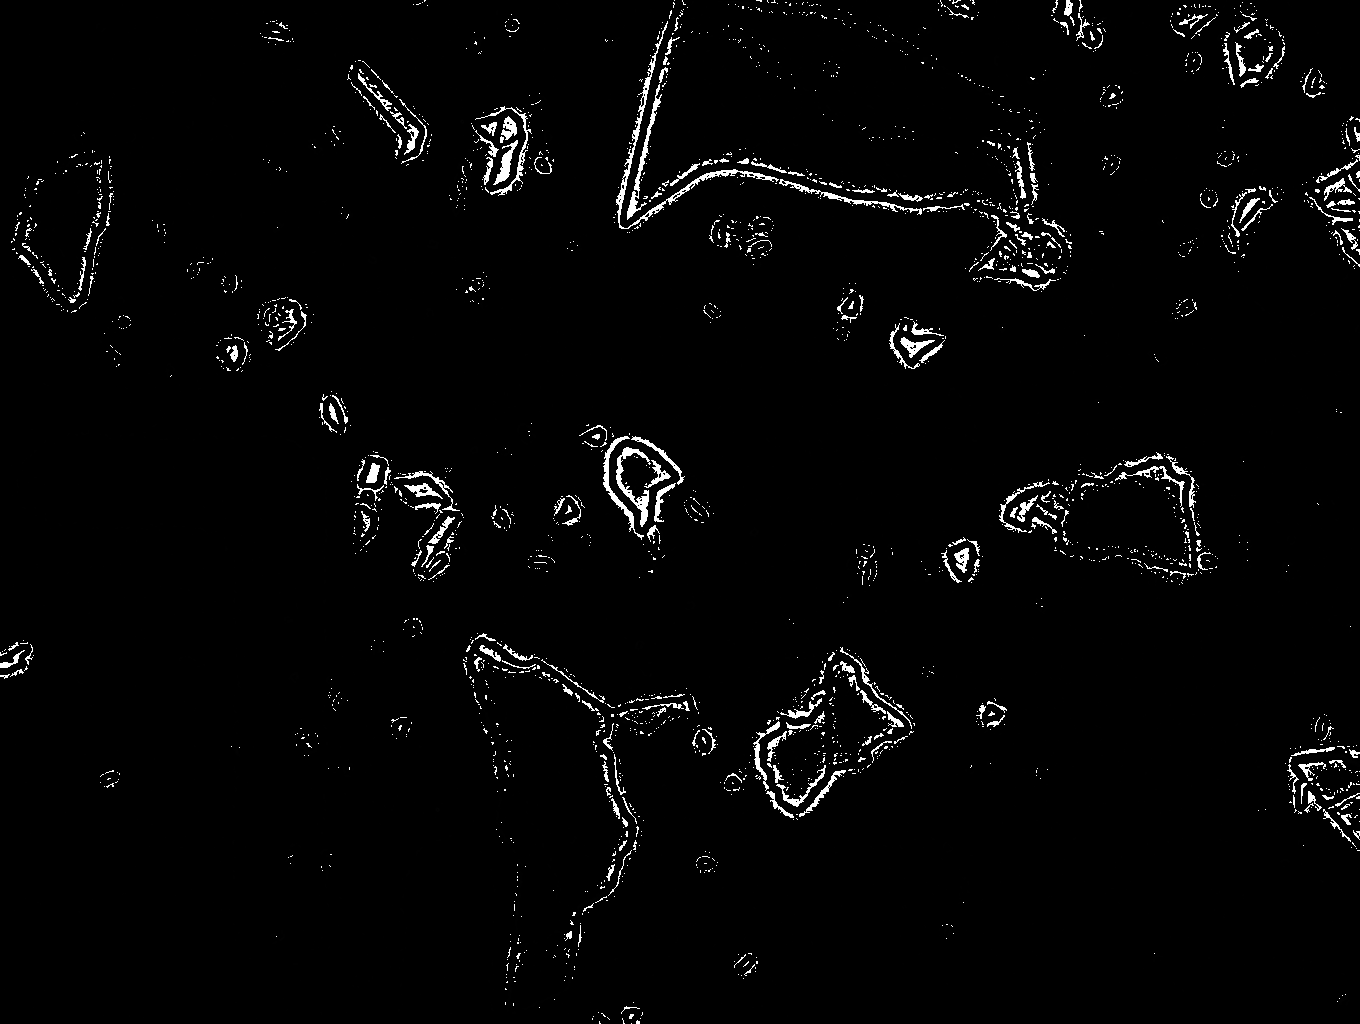

In [289]:
dog = skimage.filters.difference_of_gaussians(grayscale, 0, 5)
dog_image = Image.fromarray((dog * 255).astype(np.uint8))
dog_image

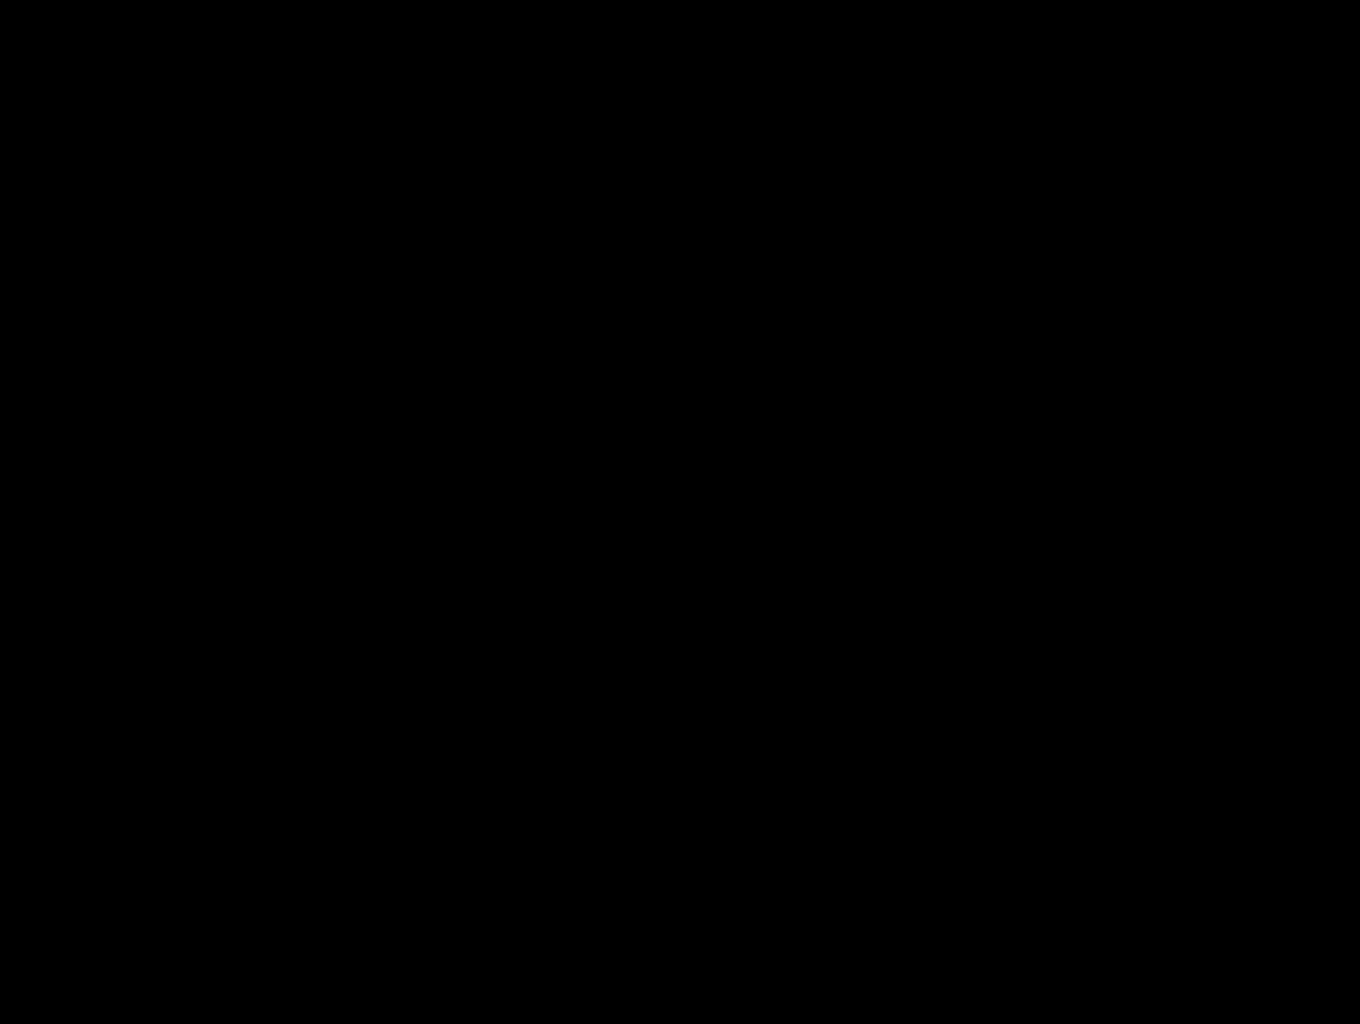

In [291]:
canny = skimage.feature.canny(~dog.astype(bool), sigma=1, mask=~label_mask)
canny_image = Image.fromarray((canny * 255).astype(np.uint8))
canny_image

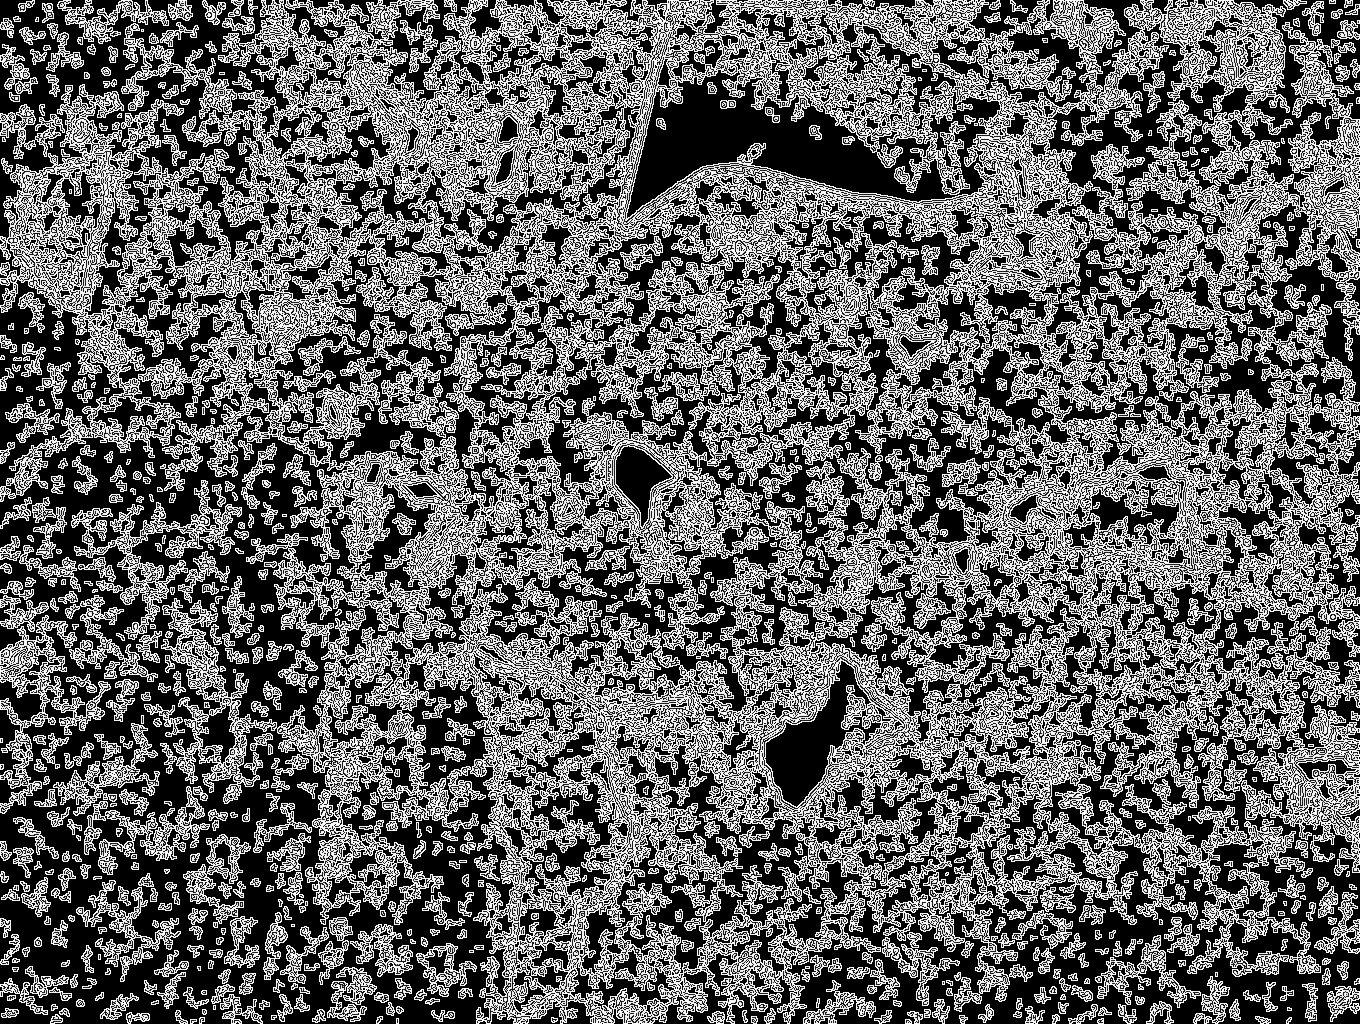

In [231]:
smoothing_sigma = 0.6 # Another knob to turn for the user.
more_dog = skimage.filters.difference_of_gaussians(canny, 0.5, smoothing_sigma)
dog_image = Image.fromarray((more_dog * 255).astype(np.uint8))
dog_image

In [232]:
_ = np.copy(more_dog)
_ = np.insert(_, 0, np.ones(more_dog.shape[-1]), axis=0)
_ = np.append(_, np.array([[1] * more_dog.shape[-1]]), axis=0)

filled_holes = scipy.ndimage.binary_fill_holes(_)
filled_holes = filled_holes[1:-1]

In [233]:
filled_holes = np.insert(filled_holes, 0, np.ones(more_dog.shape[0]), axis=1)
filled_holes = np.append(filled_holes, np.array([[1]] * more_dog.shape[0]), axis=1)
filled_holes = scipy.ndimage.binary_fill_holes(filled_holes)
filled_holes = filled_holes[:,1:-1]

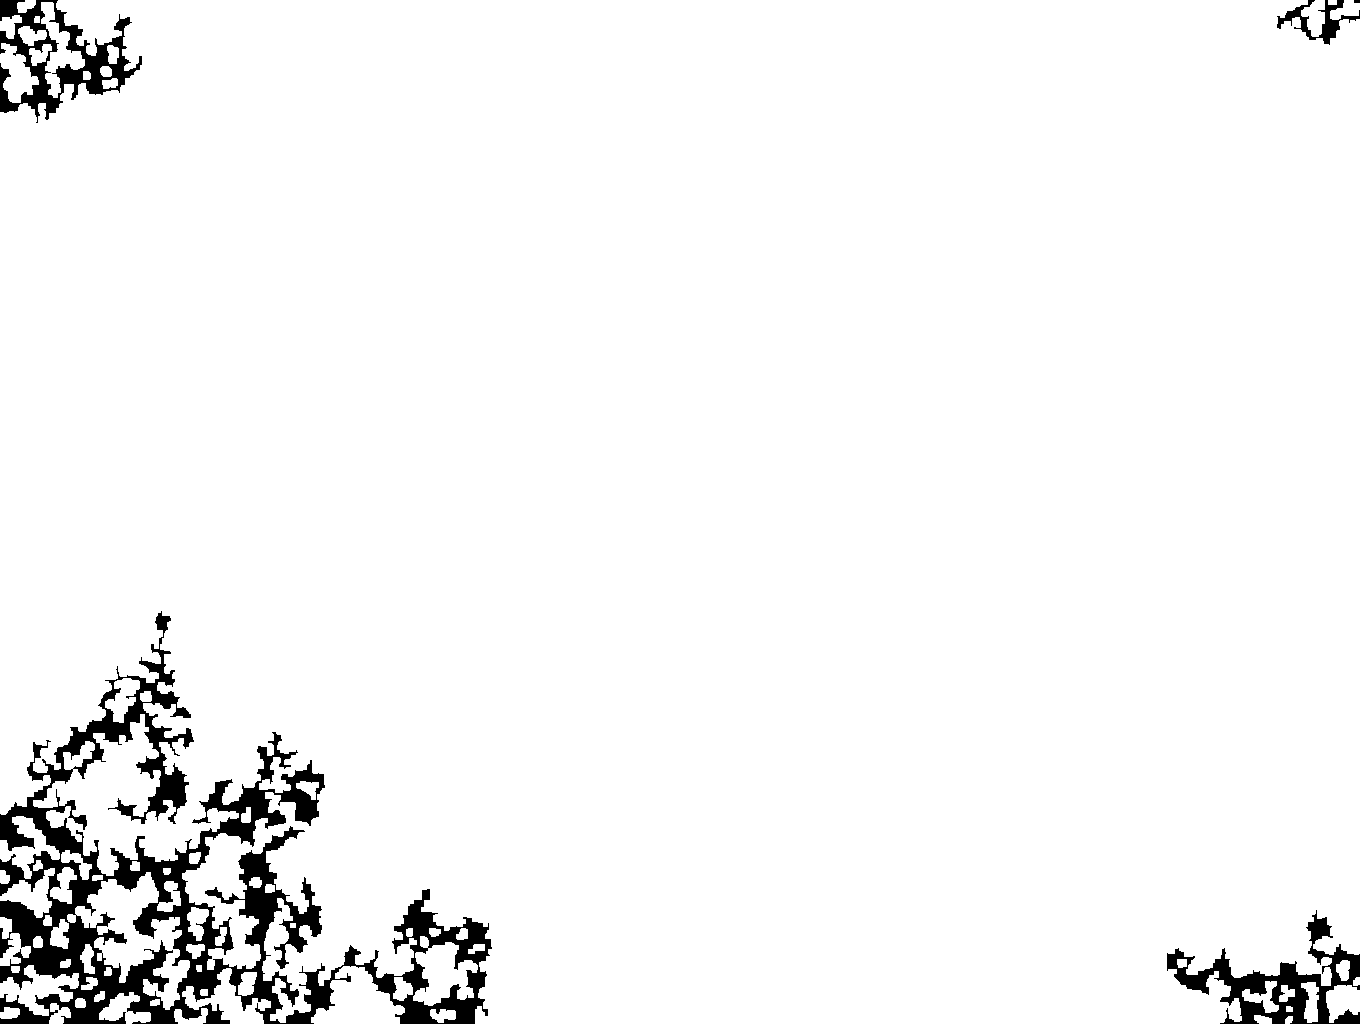

In [234]:
filled_holes_image = Image.fromarray(filled_holes.astype(bool))
filled_holes_image

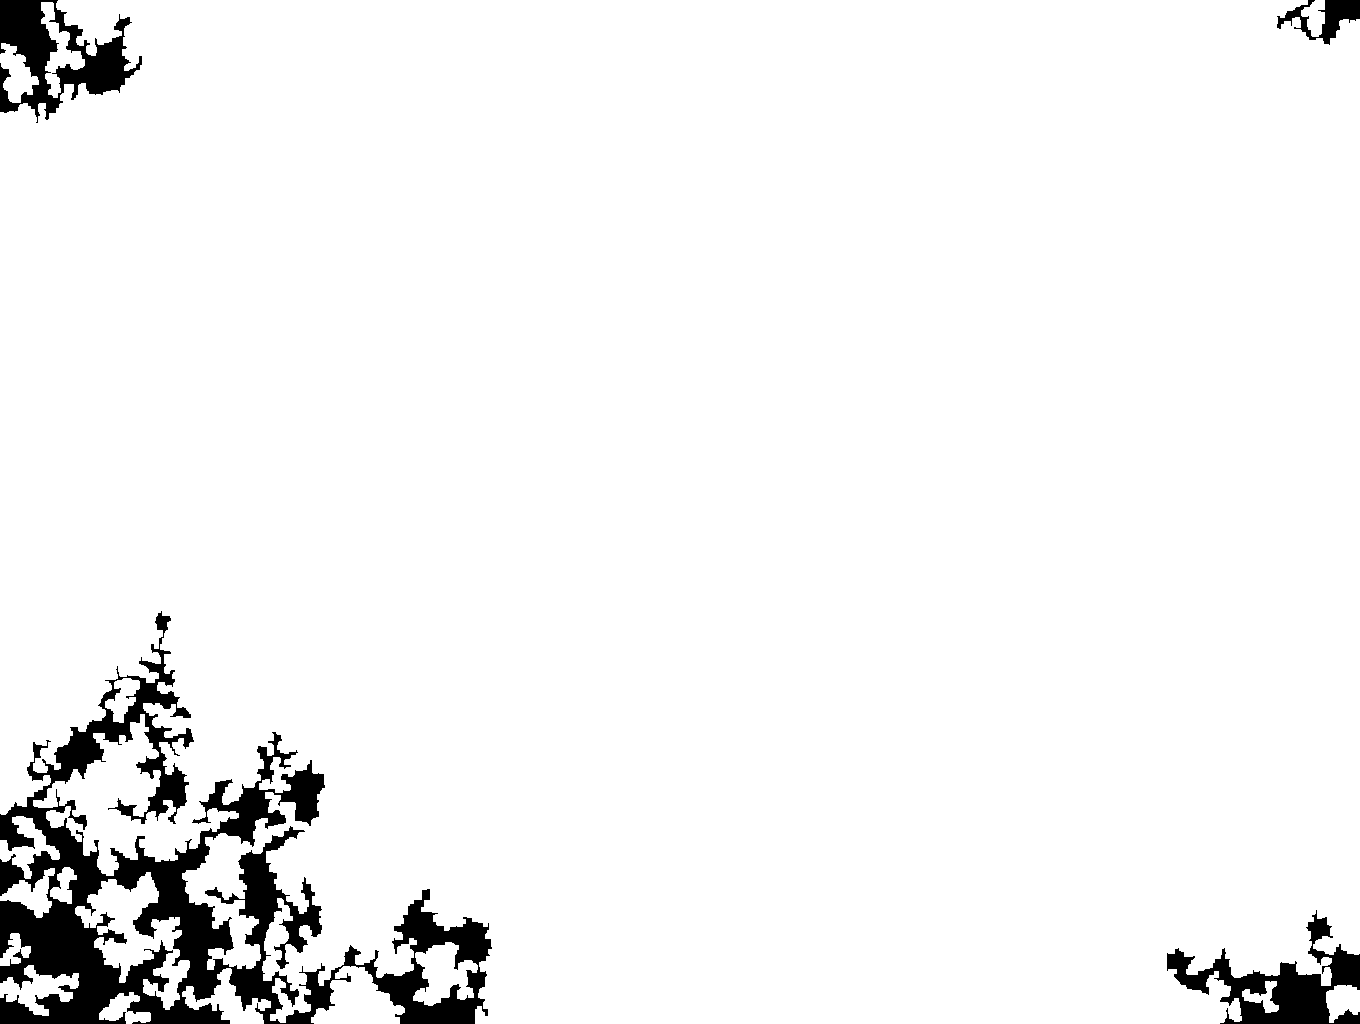

In [235]:
candidates_mask = skimage.morphology.remove_small_objects(filled_holes.astype(bool), 500)
candidates_image = Image.fromarray(candidates_mask)
candidates_image

In [236]:
final = np.copy(random_image_array)
final[~candidates_mask] = [0,0,0]

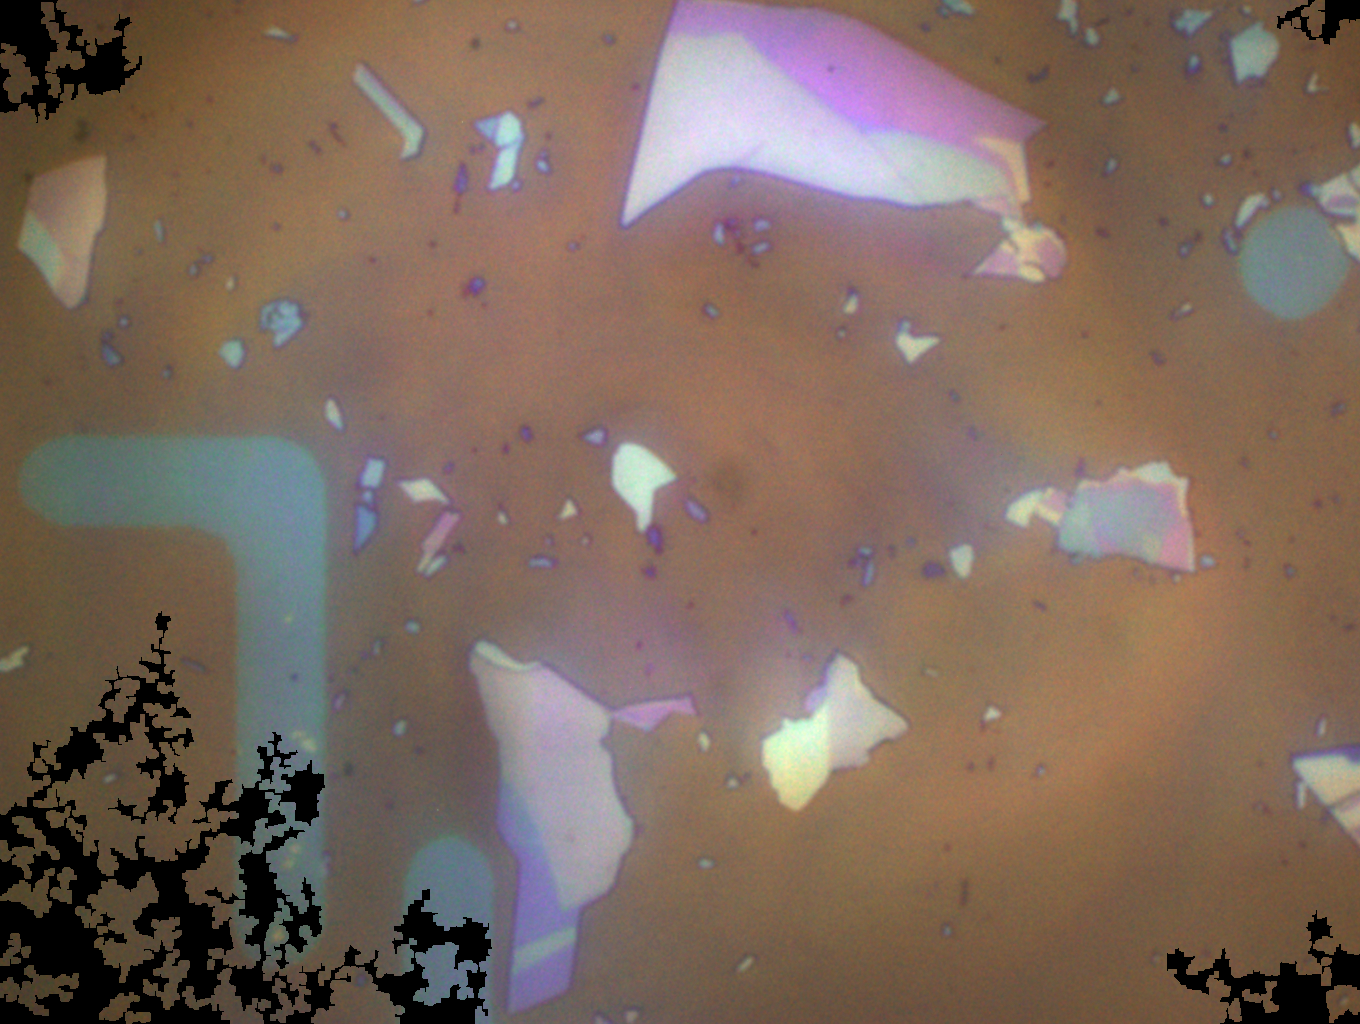

In [237]:
final_image = Image.fromarray(final)
final_image